In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

import sys
sys.path.append('../pipeline')
from comments_saver import CommentsSaver

In [7]:
cs = CommentsSaver()

Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.


In [8]:
df = cs.read_all()

In [9]:
len(df)

16565

In [10]:
councils = df['council'].unique()

In [11]:
df_council_count  = df[['council', 'stance']].groupby('council').value_counts().to_frame().reset_index()

In [12]:
df_council_count = df_council_count.pivot(index='council', columns='stance').reset_index()

In [13]:
df_council_count

council   count                 
stance                 Neutral Objects Supports
0               Barnet      13     640       51
1                Brent      73    2069      107
2       City of London      12       8       15
3               Ealing     173   10659      458
4              Lambeth      18     720      101
5               Newham       5      52        3
6            Southwark       3      80        9
7          Westminster      69    1008      219

In [14]:
df_council_count.columns = df_council_count.columns.droplevel(0)

In [15]:
df_council_count.columns = ['Council', 'Neutral', 'Objects', 'Supports']

In [16]:
df_council_count

,Council,Neutral,Objects,Supports
0,Barnet,13,640,51
1,Brent,73,2069,107
2,City of London,12,8,15
3,Ealing,173,10659,458
4,Lambeth,18,720,101
5,Newham,5,52,3
6,Southwark,3,80,9
7,Westminster,69,1008,219


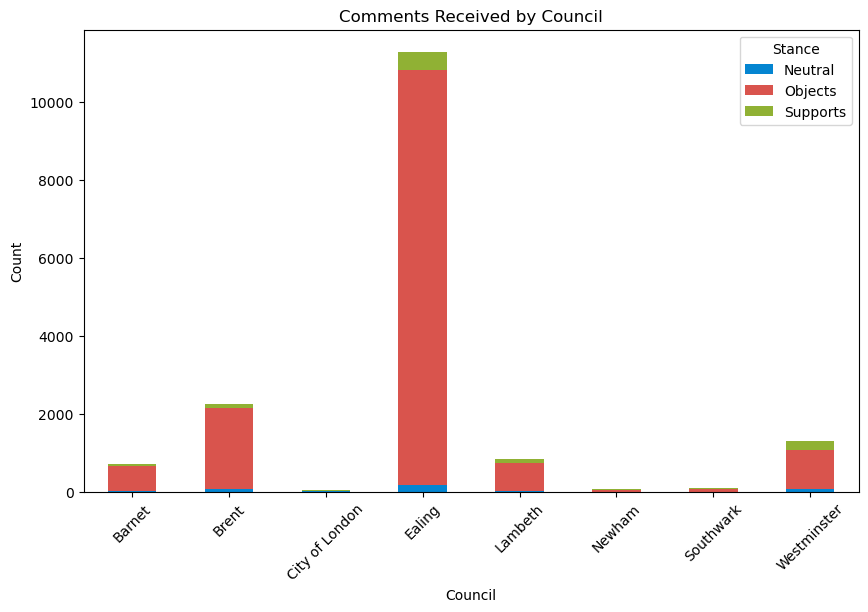

In [17]:
df_council_count.plot(
    x='Council',
    kind='bar',
    stacked=True,
    color={'Neutral': 'xkcd:cerulean', 'Objects': 'xkcd:pale red', 'Supports': 'xkcd:avocado'},
    figsize=(10, 6),
    title='Comments Received by Council'
)
plt.xlabel('Council')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.legend(title='Stance')
plt.show()

In [18]:
london_lad = gpd.read_file('../data/Local_Authority_Districts_May_2024_London.geojson')

In [19]:
london_lad

,lad_code,Area,longitude,latitude,geometry
0,E09000001,City of London,-0.093510,51.51564,"POLYGON ((533332.88 180406.812, 531312.428 180..."
1,E09000002,Barking and Dagenham,0.129479,51.54555,"POLYGON ((549992.037 181417.524, 549895.006 18..."
2,E09000003,Barnet,-0.218190,51.61107,"POLYGON ((525822.507 198220.521, 525566.689 19..."
3,E09000004,Bexley,0.146212,51.45822,"POLYGON ((550181.311 180645.759, 550636.429 18..."
4,E09000005,Brent,-0.275680,51.56438,"POLYGON ((523951.002 185545.75, 525529.383 183..."
5,E09000006,Bromley,0.039246,51.37266,"POLYGON ((544362.785 172374.32, 546620.254 170..."
6,E09000007,Camden,-0.162910,51.54305,"POLYGON ((528839.867 187215.913, 530323.717 18..."
7,E09000008,Croydon,-0.077610,51.36598,"POLYGON ((533699.518 170735.63, 534467.566 168..."
8,E09000009,Ealing,-0.314100,51.52442,"POLYGON ((521737.468 182993.864, 521351.837 17..."
9,E09000010,Enfield,-0.081440,51.64889,"POLYGON ((537543.809 199883.107, 537625.114 19..."


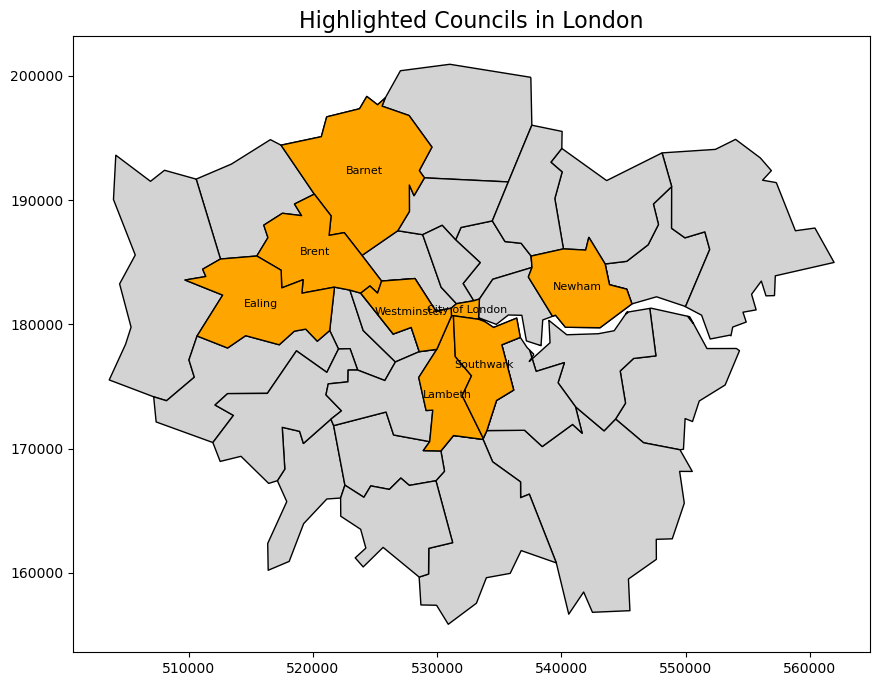

In [28]:
# Create a new column to indicate if the council is in the councils array
london_lad['highlight'] = london_lad['Area'].apply(lambda x: x in councils)

# Plot the GeoDataFrame
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
london_lad.plot(ax=ax, color='lightgrey', edgecolor='black')  # Default color for all areas
london_lad[london_lad['highlight']].plot(ax=ax, color='orange', edgecolor='black')  # Highlighted councils
# add council name for 'highlight'
for x, y, label in zip(london_lad.geometry.centroid.x, london_lad.geometry.centroid.y, london_lad['Area']):
    if label in councils:
        ax.text(x, y, label, fontsize=8, ha='center', va='center', color='black')

# Add title and legend
ax.set_title('Highlighted Councils in London', fontsize=16)
plt.show()